Project: Lung Cancer Data Analysis and Predictive Model

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

import os
print(os.getcwd())

c:\Users\rg3ca\Documents\GitHub\DATA-601-Group-Project


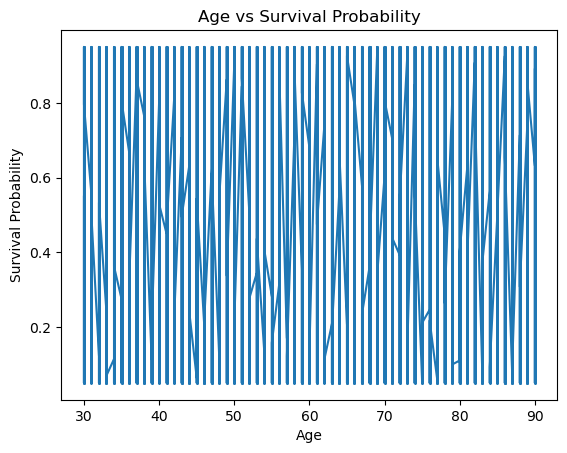

In [53]:
df_sorted = df.sort_values(by='Age')

x = df_sorted['Age']
y = df_sorted['5_Year_Survival_Probability']

plt.plot(x, y,marker = '.',ms = 1)
plt.xlabel("Age")
plt.ylabel("Survival Probability")
plt.title("Age vs Survival Probability")
plt.show()

In [ ]:
class DataHandler:

    def __init__(self,filepath):
        self.filepath = filepath
        self.df = None
        
    

    #load data
    def load(self):
        import pandas as pd
        self.df = pd.read_csv(self.filepath, keep_default_na=False)
        #keep_default_na=False is here so that "None" in the dataset isn't counted as a missing value

        #using this to visualize --Jayden 
        

    #clean data
    def clean(self):
        #remove duplicate datapoints
        self.df.drop_duplicates(inplace=True)

        #check for missing datapoints
        print("Number of missing datapoints: ", self.df.isnull().sum())
        


    #convert all categorical variables into discrete ordered/unordered values
    def transform(self, mapping = None):
        self.dfTransform = self.df.copy()
        #loop through columns to adjust for ordered values
        for col in self.dfTransform:
            if col in mapping:
                self.dfTransform[col] = self.dfTransform[col].map(mapping)
                
                #change column from object to float so that it is unaffected by get_dummies
                self.dfTransform[col] = pd.to_numeric(self.dfTransform[col], errors='coerce')
                
        
        #convert all remaining object columns into unordered values
        self.dfTransform = pd.get_dummies(self.dfTransform,drop_first=True)
        
        return self.dfTransform.copy()
       

    #condense n values into m<n bins
    def bin_variable(self,column,bins,labels):
        if column in self.df:
            self.df[column+"_Bin"] = pd.cut(self.df[column],bins=bins,labels=labels,include_lowest=True)
            

    #seperate target variable from the rest of the dataset
    def set_target(self,target):
        self.y = self.df[target]
        self.x = self.df.drop(columns=[target])


    #return cleaned data
    def get_data(self):
        return self.df.copy()


    #return x
    def get_variables(self):
        return self.x.copy()
    
    
    #return y
    def get_target(self):
        return self.y.copy()
    

    #DELETE BEFORE SUBMISSION
    #FOR DEBUGGING PURPOSES ONLY
    def diagnostic(self):
        #print(self.df.dtypes)
        #print(self.df.columns)
        pass

In [47]:
class DataVisualizer:

    def __init__(self,df):
        self.df = df

    #histograms - int/float value variables
    def histogram(self, var, bins=None):
        self.df[var].hist(bins)
        plt.title(f'{var} Histogram')
        plt.xlabel(var)
        plt.ylabel("Amount")
        plt.show()

    #bar plot - categorical variables
    def bar_chart(self, var):
        self.df[var].value_counts().plot(kind='bar')
        plt.title(f'{var} Bar Chart')
        plt.xlabel(var)
        plt.ylabel("Amount")
        plt.show()

    #variable vs target box plot
    def variable_vs_target(self, var, target):
        sns.boxplot(x=target, y=var, data=self.df)
        plt.title(f'{var} Versus {target}')
        plt.xlabel(target)
        plt.ylabel(var)
        plt.show()

    #correlation heatmap
    def corr_matrix(self):
        corr_mtx = self.df.corr()
        sns.heatmap(corr_mtx)
        plt.title("Correlation Matrix")
        plt.show()

    #find missing values w/ heatmap
    def missing(self):
        sns.heatmap(self.df.isnull(), cbar=False)
        plt.title("Missing Value Matrix")
        plt.show()


In [43]:
lungCancerData = DataHandler("lung_cancer_prediction.csv")
lungCancerData.load()
lungCancerData.clean()

#these variables have to be ordered in the analysis
lungMap = {'Air_Pollution_Exposure': {'Low':1, 'Medium':2, 'High':3},
            'Socioeconomic_Status': {'Low':1, 'Middle':2, 'High':3},
            'Stage_at_Diagnosis': {'I':1, 'II':2, 'III':3, 'IV':4},
            }


#add a bin for age so we can make an analysis based on age groups
lungCancerData.bin_variable("Age",[29,45,60,75,91],[1,2,3,4])

#convert data types from dataset to booleans for analysis
lungTransform = lungCancerData.transform(lungMap)


Number of missing datapoints:  Country                        0
Age                            0
Gender                         0
Smoking_Status                 0
Second_Hand_Smoke              0
Air_Pollution_Exposure         0
Occupation_Exposure            0
Rural_or_Urban                 0
Socioeconomic_Status           0
Healthcare_Access              0
Insurance_Coverage             0
Screening_Availability         0
Stage_at_Diagnosis             0
Cancer_Type                    0
Mutation_Type                  0
Treatment_Access               0
Clinical_Trial_Access          0
Language_Barrier               0
Mortality_Risk                 0
5_Year_Survival_Probability    0
Delay_in_Diagnosis             0
Family_History                 0
Indoor_Smoke_Exposure          0
Tobacco_Marketing_Exposure     0
Final_Prediction               0
dtype: int64


In [45]:
lungTransform.columns

Index(['Age', 'Air_Pollution_Exposure', 'Socioeconomic_Status',
       'Stage_at_Diagnosis', 'Mortality_Risk', '5_Year_Survival_Probability',
       'Country_Brazil', 'Country_China', 'Country_Colombia',
       'Country_DR Congo', 'Country_Egypt', 'Country_Ethiopia',
       'Country_France', 'Country_Germany', 'Country_India',
       'Country_Indonesia', 'Country_Iran', 'Country_Italy', 'Country_Japan',
       'Country_Kenya', 'Country_Mexico', 'Country_Myanmar', 'Country_Nigeria',
       'Country_Pakistan', 'Country_Philippines', 'Country_Russia',
       'Country_South Africa', 'Country_South Korea', 'Country_Spain',
       'Country_Tanzania', 'Country_Thailand', 'Country_Turkey', 'Country_UK',
       'Country_USA', 'Country_Vietnam', 'Gender_Male',
       'Smoking_Status_Non-Smoker', 'Smoking_Status_Smoker',
       'Second_Hand_Smoke_Yes', 'Occupation_Exposure_Yes',
       'Rural_or_Urban_Urban', 'Healthcare_Access_Limited',
       'Healthcare_Access_Poor', 'Insurance_Coverage_Yes',


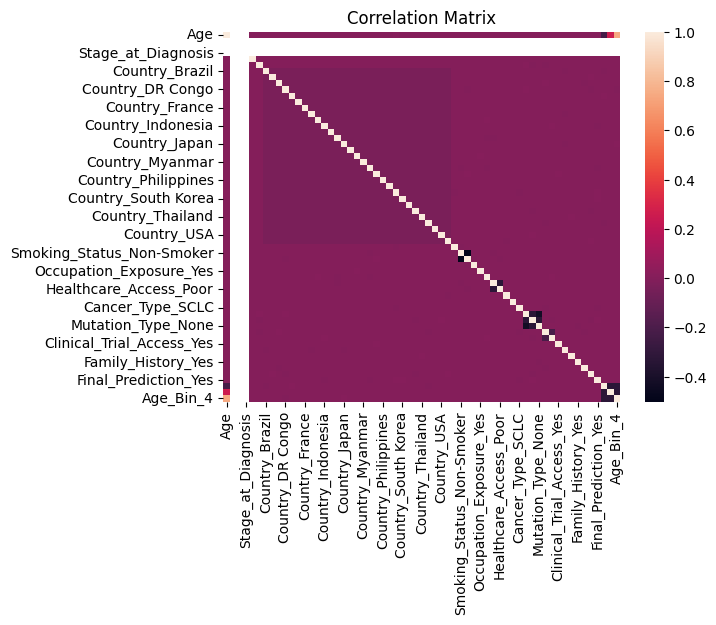

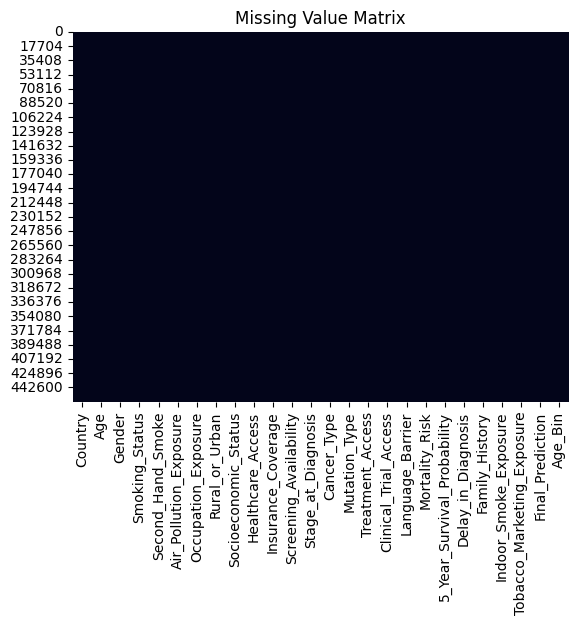

In [50]:
lungDF = lungCancerData.get_data()
lungVisual = DataVisualizer(lungDF)
lungVisualTrans = DataVisualizer(lungTransform)
lungVisualTrans.corr_matrix()
lungVisual.missing()


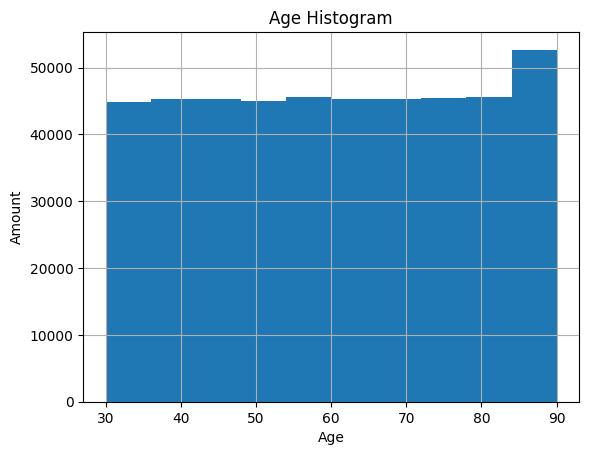

In [28]:
lungVisual.histogram("Age")


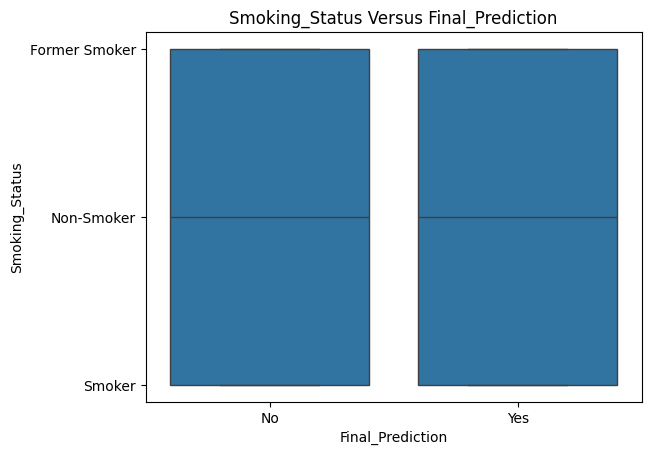

In [49]:
lungVisual.variable_vs_target("Smoking_Status","Final_Prediction")

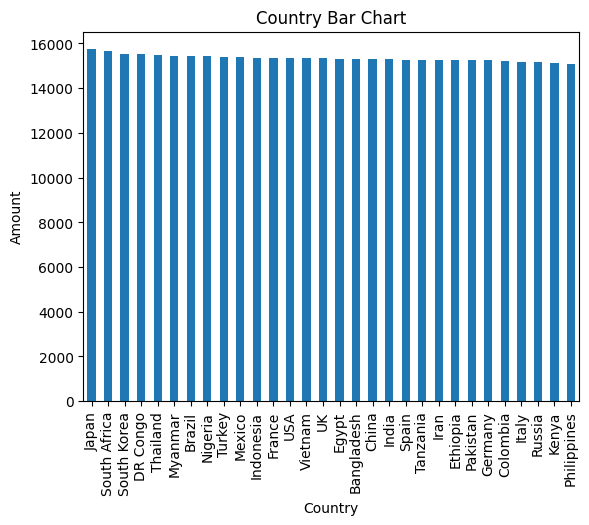

In [38]:
lungVisual.bar_chart("Country")
